# Single-Qubit State Tomography — Phase 1 Validation

Validates the new single-qubit state-tomography experiment
(`experiments/single_qubit/state_tomography_1q.py`) + MLE reconstruction core
(`fitting/state_tomography.py`) on hardware, using the job-server / worker
runner pattern (`CharacterizationRunner`), like the other QEC notebooks.

**Goal:** prepare each cardinal state, run X/Y/Z tomography, reconstruct the
density matrix, and confirm it matches expectation.

Validation logic:
- `|0>` -> Bloch +Z, `|1>` -> Bloch -Z (convention-free check),
- equatorial preps (`+`, `-`, `+i`, `-i`) -> purity ~ 1 and lie in the
  equatorial plane, mutually consistent (antipodal pairs, orthogonal axes),
- fidelity to the nominal ideal kets under the assumed pulse convention.

If an equatorial axis comes out swapped or sign-flipped, that is purely the
pulse/axis convention — adjust `tomo_phases` (defaults `{'X':90,'Y':0}`). The
reconstruction math itself is unit-tested offline in
`tests/test_state_tomography_1q.py`.


## Setup (station + job client)

In [15]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from tqdm.notebook import tqdm
from pathlib import Path

import experiments as meas
from experiments.MM_dual_rail_base import MM_dual_rail_base
from experiments import MultimodeStation, CharacterizationRunner
from fitting.state_tomography import (
    reconstruct_single_qubit, state_fidelity, PX, PY, PZ,
)

from slab import AttrDict
from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

# Database + config manager
db = get_database()
config_dir = str(Path.cwd().parent.parent / 'configs')
config_manager = ConfigVersionManager(config_dir)

# Job client (submits to queue, worker executes on hardware)
client = JobClient()
health = client.health_check()
print(f"Server status: {health['status']}")
print(f"Pending jobs: {health['pending_jobs']}")

user = "seb"
print("Welcome", user)

station = MultimodeStation(
    user=user,
    experiment_name="260601_StateTomo1Q_validation",
    project="Transduction",
    log_measurements=True,
)

USE_QUEUE = True

mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soccfg)


active_reset_dict = {
    'active_reset': True, # on recalibration of readout, turn off active reset because it will be wrong for selecting when to apply the qubit pulse
    'ef_reset': True,
    'storage_reset': False,
    'coupler_reset': False,
    'pre_selection_reset': True,
    'man_reset': False, 
    'use_qubit_man_reset': True, # whether to use the qubit
    'pre_selection_parity':True,
}


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Server status: healthy
Pending jobs: 0
Welcome seb
[STATION] Using main hardware_config version: CFG-HW-20260601-00059
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using main man1_storage_swap version: CFG-M1-20260528-00074
[STATION] Using main floquet_storage_swap version: CFG-FL-20260223-00024
[STATION] Lab-notebook vault: G:\Shared drives\SLab\Multimode
Data, plots, logs will be stored in: C:\experiments\260601_StateTomo1Q_validation
Hardware configs will be read from C:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260601-00059.yml
dict_keys(['Pyro.NameServer', 'Qick101'])
QICK running on ZCU216, software version 0.2.291

Firmware configuration (built Tue Oct 15 12:06:51 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 us)
		fs=

## Defaults, prep sequences, and preprocessor

`prep_state` selects the cardinal state; the preprocessor turns it into the
gate-based `state_prep_seq` the experiment compiles. All prep pulses and the
tomography pre-rotations use the same `ge` hpi/pi phase convention.

**Active reset is ge/ef-only here.** This is a *bare-qubit* experiment with no
cavity population, so `man_reset`/`storage_reset` are OFF. (The codebase
default `get_active_reset_params` turns them ON for cavity experiments; leaving
them on runs ~7 storage<->manipulate flux swaps after the qubit reset, which
disturbs/re-excites the bare qubit and washes out the tomography signal.)


In [25]:
tomo_defaults = AttrDict(dict(
    reps=2000,
    rounds=1,
    qubits=[0],
    state_prep_seq=[],        # gate-based prep; set from prep_state in preproc
    prep_state=None,          # '0','1','+','-','+i','-i'
    tomo_phases={'X': 90, 'Y': 0},
    state_prep_postselect=False,
    recon_method='fast',      # 'fast' | 'cholesky' | 'linear'
    relax_delay=2500,
    **active_reset_dict,
))

# Gate-based prep for each cardinal state (ge manifold).
PREP_SEQS = {
    '0':  [],
    '1':  [['qubit', 'ge', 'pi', 0]],
    '+':  [['qubit', 'ge', 'hpi', 270]],   # -> +X
    '-':  [['qubit', 'ge', 'hpi', 90]],    # -> -X
    '+i': [['qubit', 'ge', 'hpi', 180]],   # -> +Y
    '-i': [['qubit', 'ge', 'hpi', 0]],     # -> -Y
}


# Nominal ideal kets (assumed convention; adjust if validation shows a flip).
IDEAL_KETS = {
    '0':  np.array([1, 0], dtype=complex),
    '1':  np.array([0, 1], dtype=complex),
    '+':  np.array([1, 1], dtype=complex) / np.sqrt(2),
    '-':  np.array([1, -1], dtype=complex) / np.sqrt(2),
    '+i': np.array([1, 1j], dtype=complex) / np.sqrt(2),
    '-i': np.array([1, -1j], dtype=complex) / np.sqrt(2),
}

def tomo_preproc(station, default_expt_cfg, **kwargs):
    cfg = deepcopy(default_expt_cfg)
    cfg.update(kwargs)
    if cfg.get('prep_state') is not None:
        cfg.state_prep_seq = deepcopy(PREP_SEQS[cfg.prep_state])
    return cfg

def bloch_vector(rho):
    return np.array([np.real(np.trace(rho @ PX)),
                     np.real(np.trace(rho @ PY)),
                     np.real(np.trace(rho @ PZ))])

def purity(rho):
    return float(np.real(np.trace(rho @ rho)))

## Runner

In [17]:
tomo_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.StateTomography1QExperiment,
    default_expt_cfg=tomo_defaults,
    preprocessor=tomo_preproc,
    postprocessor=None,
    job_client=client,
    use_queue=USE_QUEUE,
)

## Control / debug — isolate readout, prep, and reset FIRST

Before trusting the full tomography, confirm the basics. `<Z>` must clearly
separate for `|0>` vs `|1>`:
- `|0>` -> `<Z> ~ +1`, `|1>` -> `<Z> ~ -1`.

If they don't separate, the **readout threshold is stale** -> recalibrate a
single-shot histogram and update `cfg.device.readout.threshold`.

If `|0>` is not near `+1` even in Z (qubit reads excited), the **reset isn't
landing in ground** -> try `active_reset=False` with a long `relax_delay`
(e.g. 200000), or check the ge/ef reset threshold.


Job submitted: JOB-20260601-00236 (queue position: 1)

[0.1s] Job JOB-20260601-00236: pending

[2.1s] Job JOB-20260601-00236: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00236_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 61%|██████████████████████▋              | 1227/2000 [00:03<00:01, 396.47it/s]
[22.3s] Job JOB-20260601-00236: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.15s/it]
Reconstructed rho:
[[0.9691+0.j     0.0131-0.0092j]
 [0.0131+0.0092j 0.0309-0.j    ]]
counts (n_g, n_e) per basis: {'Z': (1754, 56), 'X': (904, 858), 'Y': (909, 876)}
Saving C:\experiments\260601_StateTomo1Q_validation\data\JOB-20260601-00236_StateTomography1QExperiment.h5
[WORKER] Saving expt object to: C:

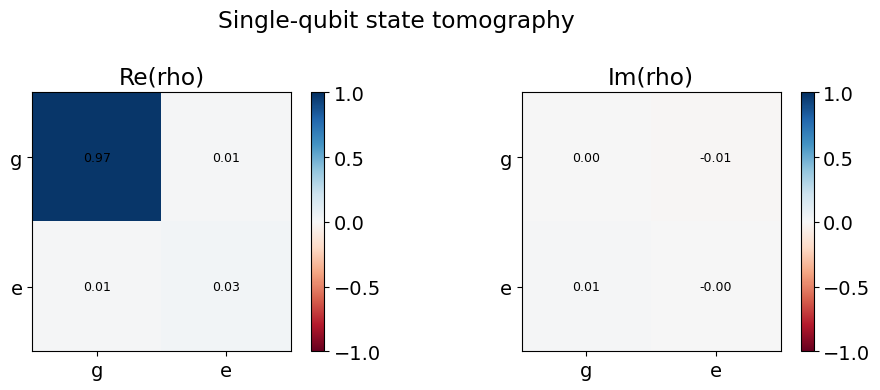

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[0.9691+0.j     0.0131-0.0092j]
 [0.0131+0.0092j 0.0309-0.j    ]]
counts (n_g, n_e) per basis: {'Z': (1754, 56), 'X': (904, 858), 'Y': (909, 876)}
prep |0>: counts(n_g,n_e)/basis = {'Z': (1754, 56), 'X': (904, 858), 'Y': (909, 876)},  <Z> = +0.938
Job submitted: JOB-20260601-00237 (queue position: 1)

[0.0s] Job JOB-20260601-00237: pending

[2.0s] Job JOB-20260601-00237: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00237_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 61%|██████████████████████▋              | 1227/2000 [00:03<00:01, 397.30it/s]
[22.1s] Job JOB-20260601-00237: completed
basis: 

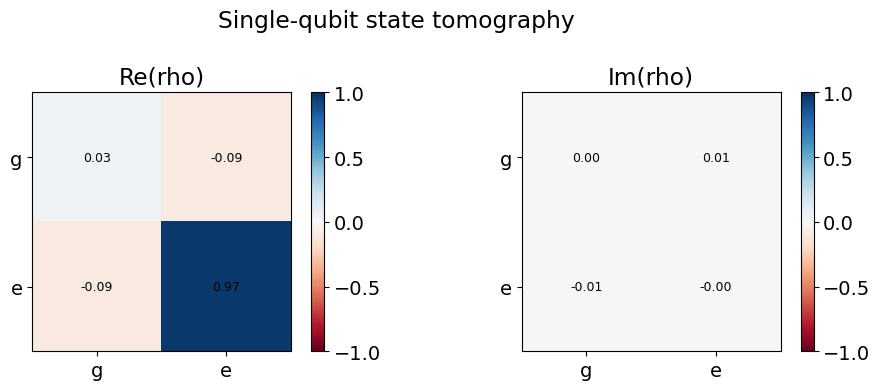

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[ 0.0326+0.j    -0.0893+0.005j]
 [-0.0893-0.005j  0.9674-0.j   ]]
counts (n_g, n_e) per basis: {'Z': (58, 1721), 'X': (734, 1053), 'Y': (886, 904)}
prep |1>: counts(n_g,n_e)/basis = {'Z': (58, 1721), 'X': (734, 1053), 'Y': (886, 904)},  <Z> = -0.935

<Z>(|0>) - <Z>(|1>) = +1.873  (expect ~ +2 if readout+prep are healthy)


In [18]:
ctrl = {}
for s in ['0', '1']:
    e = tomo_runner.execute(prep_state=s, reps=2000)
    e.analyze()
    rho = e.data['rho']
    ez = float(np.real(np.trace(rho @ PZ)))
    ctrl[s] = (e.data['counts'], ez)
    print(f"prep |{s}>: counts(n_g,n_e)/basis = {e.data['counts']},  <Z> = {ez:+.3f}")

dz = ctrl['0'][1] - ctrl['1'][1]
print(f"\n<Z>(|0>) - <Z>(|1>) = {dz:+.3f}  (expect ~ +2 if readout+prep are healthy)")
if dz < 1.0:
    print("WARNING: poor Z separation -> recalibrate readout threshold and/or reset.")

Job submitted: JOB-20260601-00238 (queue position: 1)

[0.0s] Job JOB-20260601-00238: pending

[2.0s] Job JOB-20260601-00238: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00238_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 72%|██████████████████████████▍          | 2863/4000 [00:07<00:02, 397.42it/s]
[36.3s] Job JOB-20260601-00238: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:30<00:00, 10.19s/it]
Reconstructed rho:
[[ 0.9693+0.j    -0.0071-0.002j]
 [-0.0071+0.002j  0.0307+0.j   ]]
counts (n_g, n_e) per basis: {'Z': (3440, 109), 'X': (1764, 1815), 'Y': (1796, 1782)}
Saving C:\experiments\260601_StateTomo1Q_validation\data\JOB-20260601-00238_StateTomography1QExperiment.h5
[WORKER] Saving expt object t

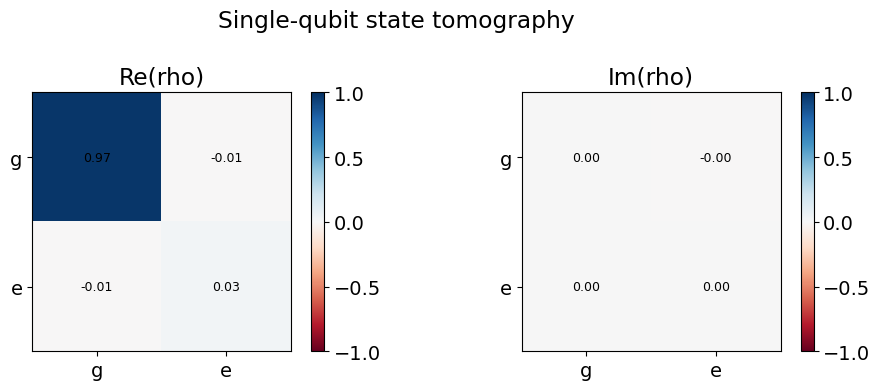

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md


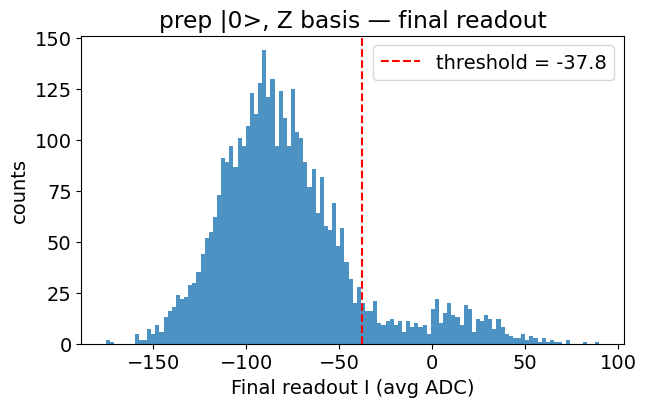

fraction above threshold (called |e|): 0.116   (expect small for a good ground prep)


In [19]:
# Raw final-readout histogram for prep |0>, Z basis: see where the blob sits
# relative to the threshold. A healthy ground prep sits mostly on the g side.
e = tomo_runner.execute(prep_state='0', reps=4000)
i0 = e.data['i0_Z']
rn = e.data['read_num']
th = e.cfg.device.readout.threshold[0]
final = i0[:, rn - 1]   # last lane = tomography readout

plt.figure(figsize=(7, 4))
plt.hist(final, bins=120, alpha=0.8)
plt.axvline(th, color='r', linestyle='--', label=f'threshold = {th:.3g}')
plt.xlabel('Final readout I (avg ADC)'); plt.ylabel('counts')
plt.title('prep |0>, Z basis — final readout'); plt.legend()
plt.show()
print('fraction above threshold (called |e|):', round(float(np.mean(final > th)), 3),
      '  (expect small for a good ground prep)')

## Single-state smoke test

Once the control above looks healthy, run one state end-to-end and inspect the
reconstructed density matrix.


Job submitted: JOB-20260601-00239 (queue position: 1)

[0.0s] Job JOB-20260601-00239: pending

[2.0s] Job JOB-20260601-00239: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00239_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 61%|██████████████████████▋              | 1227/2000 [00:03<00:01, 396.23it/s]
[22.1s] Job JOB-20260601-00239: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.17s/it]
Reconstructed rho:
[[ 0.0404+0.j     -0.0842-0.0062j]
 [-0.0842+0.0062j  0.9596+0.j    ]]
counts (n_g, n_e) per basis: {'Z': (72, 1711), 'X': (731, 1027), 'Y': (900, 878)}
Saving C:\experiments\260601_StateTomo1Q_validation\data\JOB-20260601-00239_StateTomography1QExperiment.h5
[WORKER] Saving expt object t

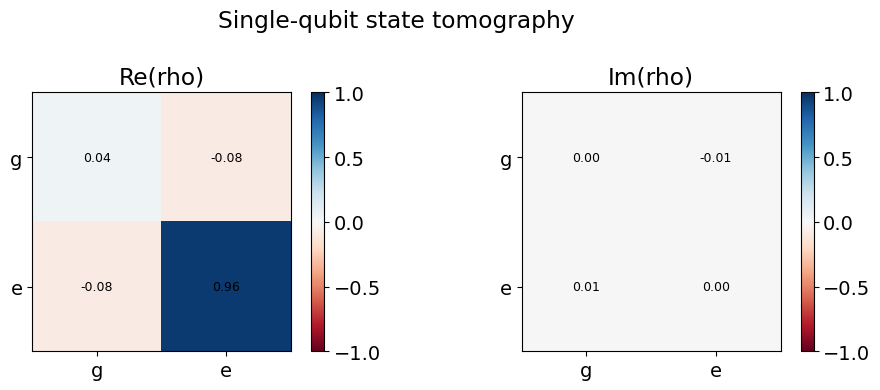

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[ 0.0404+0.j     -0.0842-0.0062j]
 [-0.0842+0.0062j  0.9596+0.j    ]]
counts (n_g, n_e) per basis: {'Z': (72, 1711), 'X': (731, 1027), 'Y': (900, 878)}


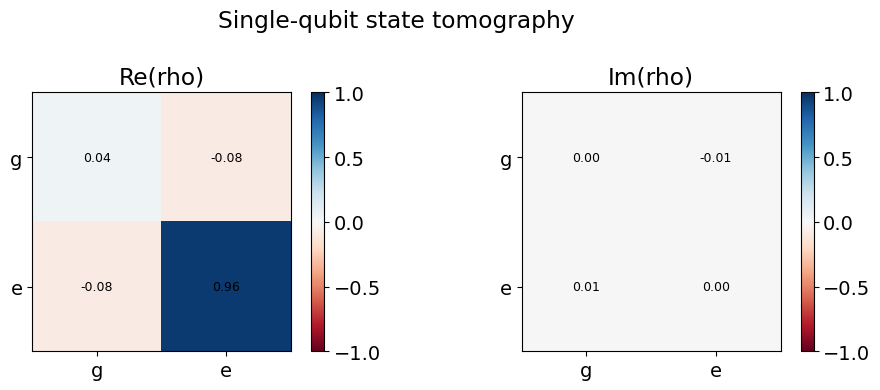

Bloch vector (x,y,z): [-0.168  0.012 -0.919]
Purity: 0.937
Fidelity to |1>: 0.9596


In [20]:
expt = tomo_runner.execute(prep_state='1', reps=2000)
expt.analyze()
expt.display()

rho = expt.data['rho']
print('Bloch vector (x,y,z):', np.round(bloch_vector(rho), 3))
print('Purity:', round(purity(rho), 3))
print('Fidelity to |1>:', round(state_fidelity(rho, IDEAL_KETS['1']), 4))

## All cardinal states

confusion [Pgg, Pge, Peg, Pee]: [0.971869328493648, 0.028130671506351956, 0.03955056179775283, 0.9604494382022472]
Job submitted: JOB-20260601-00280 (queue position: 1)

[0.0s] Job JOB-20260601-00280: pending

[2.0s] Job JOB-20260601-00280: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00280_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 41%|███████████████▌                      | 818/2000 [00:02<00:02, 394.12it/s]
[24.2s] Job JOB-20260601-00280: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.16s/it]
Reconstructed rho:
[[0.4963+0.j     0.0469-0.4978j]
 [0.0469+0.4978j 0.5037+0.j    ]]
counts (n_g, n_e) per basis: {'Z': (906, 898), 'X': (986, 808), 'Y': (1748, 47)}
Saving C:\experiments\2606

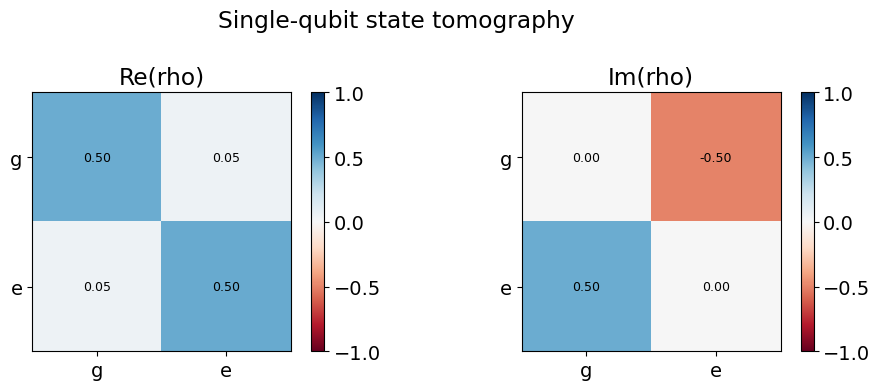

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[0.4963+0.j     0.0469-0.4978j]
 [0.0469+0.4978j 0.5037+0.j    ]]
counts (n_g, n_e) per basis: {'Z': (906, 898), 'X': (986, 808), 'Y': (1748, 47)}


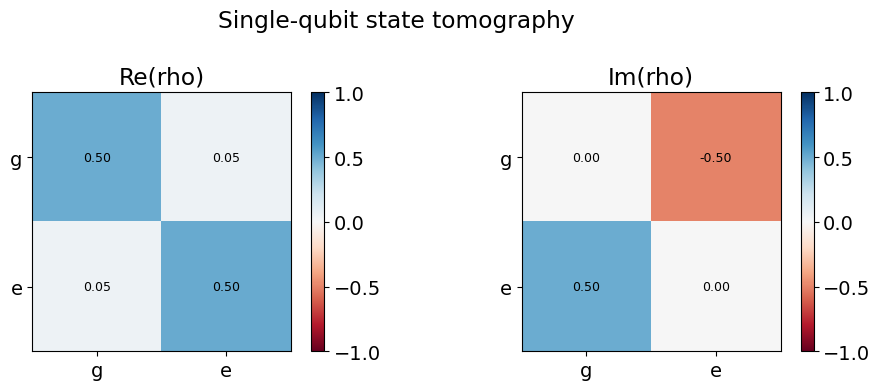

In [26]:
# confusion matrix saved by the single-shot calibration (active reset ON)
conf = station.hardware_cfg.device.readout.confusion_matrix_with_active_reset
conf = [float(x) for x in conf]          # plain floats -> JSON-safe for the worker
print('confusion [Pgg, Pge, Peg, Pee]:', conf)

expt = tomo_runner.execute(prep_state='+i', reps=2000, confusion=conf)
expt.analyze()
expt.display()


cardinal states:   0%|          | 0/6 [00:00<?, ?it/s]

Job submitted: JOB-20260601-00281 (queue position: 1)

[0.0s] Job JOB-20260601-00281: pending

[2.0s] Job JOB-20260601-00281: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00281_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 41%|███████████████▌                      | 818/2000 [00:02<00:02, 396.81it/s]
[22.3s] Job JOB-20260601-00281: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.16s/it]
Reconstructed rho:
[[0.9851+0.j     0.0288-0.0144j]
 [0.0288+0.0144j 0.0149+0.j    ]]
counts (n_g, n_e) per basis: {'Z': (1783, 27), 'X': (954, 850), 'Y': (929, 877)}
Saving C:\experiments\260601_StateTomo1Q_validation\data\JOB-20260601-00281_StateTomography1QExperiment.h5
[WORKER] Saving expt object to: C:

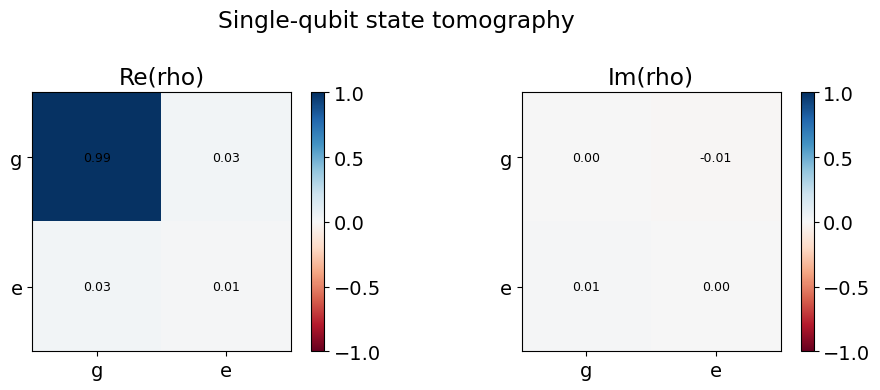

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[0.9851+0.j     0.0288-0.0144j]
 [0.0288+0.0144j 0.0149+0.j    ]]
counts (n_g, n_e) per basis: {'Z': (1783, 27), 'X': (954, 850), 'Y': (929, 877)}
Job submitted: JOB-20260601-00282 (queue position: 1)

[0.0s] Job JOB-20260601-00282: pending

[2.0s] Job JOB-20260601-00282: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00282_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 41%|███████████████▌                      | 818/2000 [00:02<00:02, 396.40it/s]
[22.1s] Job JOB-20260601-00282: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.16s/it]
Reconstructed rho:
[[ 0.0424

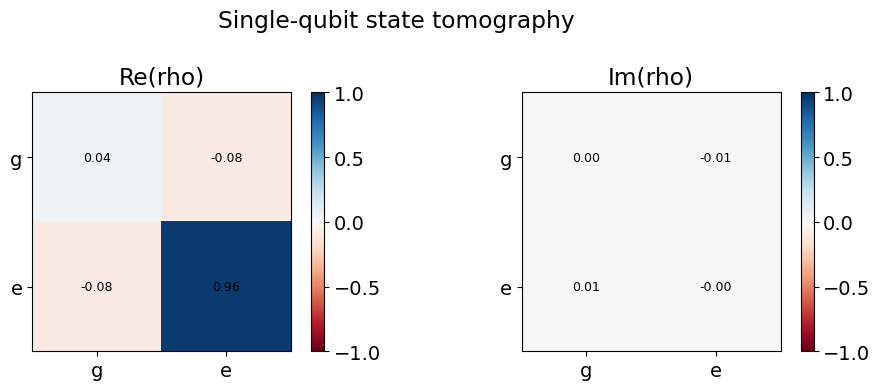

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[ 0.0424+0.j     -0.082 -0.0061j]
 [-0.082 +0.0061j  0.9576-0.j    ]]
counts (n_g, n_e) per basis: {'Z': (76, 1715), 'X': (742, 1033), 'Y': (917, 895)}
Job submitted: JOB-20260601-00283 (queue position: 1)

[0.0s] Job JOB-20260601-00283: pending

[2.0s] Job JOB-20260601-00283: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00283_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 82%|██████████████████████████████▎      | 1636/2000 [00:04<00:00, 397.81it/s]
[24.2s] Job JOB-20260601-00283: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.17s/it]
Reconstructed rho:
[[0.

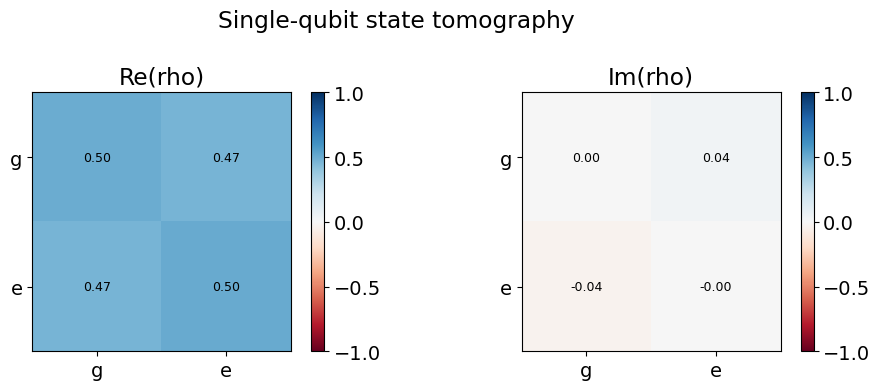

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[0.4981+0.j     0.4681+0.0353j]
 [0.4681-0.0353j 0.5019-0.j    ]]
counts (n_g, n_e) per basis: {'Z': (895, 902), 'X': (1732, 57), 'Y': (835, 962)}
Job submitted: JOB-20260601-00284 (queue position: 1)

[0.0s] Job JOB-20260601-00284: pending

[2.0s] Job JOB-20260601-00284: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00284_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 61%|██████████████████████▋              | 1227/2000 [00:03<00:01, 396.54it/s]
[24.1s] Job JOB-20260601-00284: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.18s/it]
Reconstructed rho:
[[ 0.4959

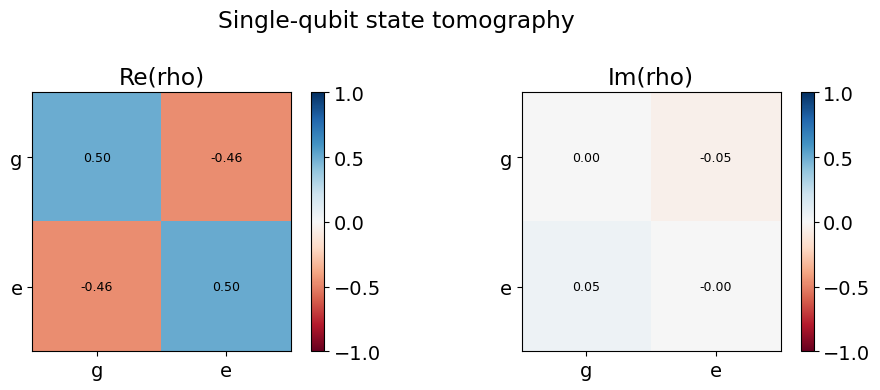

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[ 0.4959+0.j     -0.4621-0.0498j]
 [-0.4621+0.0498j  0.5041-0.j    ]]
counts (n_g, n_e) per basis: {'Z': (905, 920), 'X': (68, 1724), 'Y': (993, 813)}
Job submitted: JOB-20260601-00285 (queue position: 1)

[0.0s] Job JOB-20260601-00285: pending

[2.0s] Job JOB-20260601-00285: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00285_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 61%|██████████████████████▋              | 1227/2000 [00:03<00:01, 396.86it/s]
[22.2s] Job JOB-20260601-00285: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.16s/it]
Reconstructed rho:
[[0.4

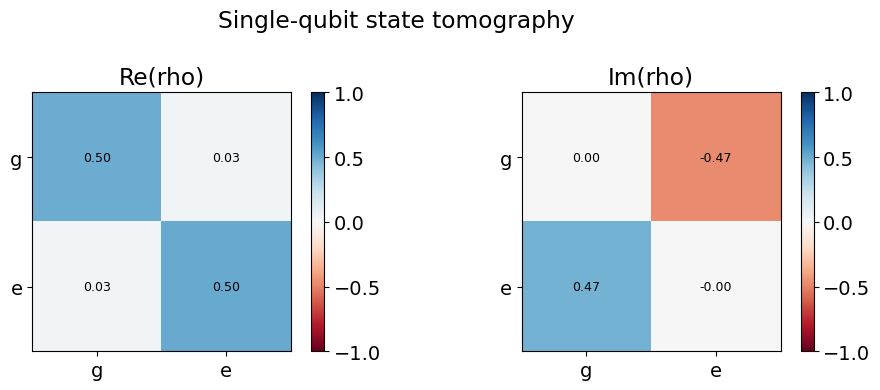

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[0.498 +0.j     0.0282-0.4749j]
 [0.0282+0.4749j 0.502 -0.j    ]]
counts (n_g, n_e) per basis: {'Z': (891, 898), 'X': (947, 846), 'Y': (1751, 45)}
Job submitted: JOB-20260601-00286 (queue position: 1)

[0.0s] Job JOB-20260601-00286: pending

[2.0s] Job JOB-20260601-00286: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00286_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 61%|██████████████████████▋              | 1227/2000 [00:03<00:01, 396.18it/s]
[22.1s] Job JOB-20260601-00286: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.17s/it]
Reconstructed rho:
[[ 0.5249

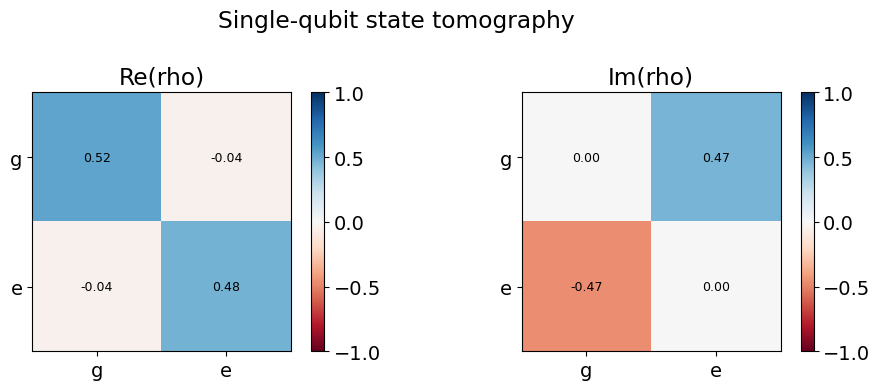

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[ 0.5249+0.j     -0.0429+0.4652j]
 [-0.0429-0.4652j  0.4751+0.j    ]]
counts (n_g, n_e) per basis: {'Z': (947, 857), 'X': (826, 981), 'Y': (63, 1749)}
state      rx      ry      rz  purity     fid
    0   0.058   0.029   0.970   0.973  0.9851
    1  -0.164   0.012  -0.915   0.932  0.9576
    +   0.936  -0.071  -0.004   0.941  0.9681
    -  -0.924   0.100  -0.008   0.932  0.9621
   +i   0.056   0.950  -0.004   0.953  0.9749
   -i  -0.086  -0.930   0.050   0.938  0.9652


In [27]:
states = ['0', '1', '+', '-', '+i', '-i']
rhos = {}
rows = []

for s in tqdm(states, desc='cardinal states'):
    expt = tomo_runner.execute(prep_state=s, reps=2000)
    expt.analyze()
    rho = expt.data['rho']
    rhos[s] = rho
    b = bloch_vector(rho)
    fid = state_fidelity(rho, IDEAL_KETS[s])
    rows.append((s, b[0], b[1], b[2], purity(rho), fid))

print(f"{'state':>5} {'rx':>7} {'ry':>7} {'rz':>7} {'purity':>7} {'fid':>7}")
for s, rx, ry, rz, pur, fid in rows:
    print(f"{s:>5} {rx:7.3f} {ry:7.3f} {rz:7.3f} {pur:7.3f} {fid:7.4f}")

## Validation checks + Bloch-sphere view

|0> rz = +0.970 (expect ~ +1)
|1> rz = -0.915 (expect ~ -1)
+/- antipodal? cos(angle) = -0.999 (expect ~ -1)
+i/-i antipodal? cos(angle) = -0.998 (expect ~ -1)
(+/-) axis _|_ (+i/-i) axis? cos(angle) = -0.016 (expect ~ 0)
mean purity: 0.945


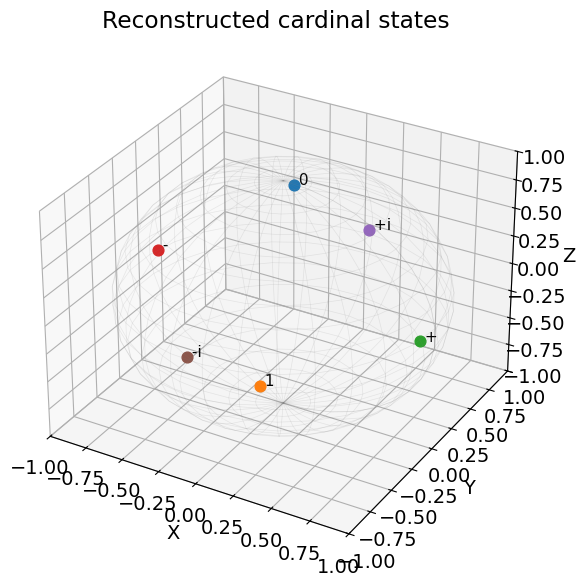

In [28]:
# Convention-free checks
b0 = bloch_vector(rhos['0']); b1 = bloch_vector(rhos['1'])
print(f"|0> rz = {b0[2]:+.3f} (expect ~ +1)")
print(f"|1> rz = {b1[2]:+.3f} (expect ~ -1)")

for pair in [('+', '-'), ('+i', '-i')]:
    ba, bb = bloch_vector(rhos[pair[0]]), bloch_vector(rhos[pair[1]])
    dot = np.dot(ba, bb) / (np.linalg.norm(ba) * np.linalg.norm(bb) + 1e-12)
    print(f"{pair[0]}/{pair[1]} antipodal? cos(angle) = {dot:+.3f} (expect ~ -1)")

axis_pm = bloch_vector(rhos['+']) - bloch_vector(rhos['-'])
axis_pmi = bloch_vector(rhos['+i']) - bloch_vector(rhos['-i'])
ortho = np.dot(axis_pm, axis_pmi) / (
    np.linalg.norm(axis_pm) * np.linalg.norm(axis_pmi) + 1e-12)
print(f"(+/-) axis _|_ (+i/-i) axis? cos(angle) = {ortho:+.3f} (expect ~ 0)")
print('mean purity:', round(np.mean([purity(r) for r in rhos.values()]), 3))

# Bloch-sphere scatter
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:20j]
ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                  color='gray', alpha=0.15, linewidth=0.5)
for s in states:
    b = bloch_vector(rhos[s])
    ax.scatter(*b, s=60)
    ax.text(b[0], b[1], b[2], f' {s}', fontsize=11)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
ax.set_title('Reconstructed cardinal states')
plt.tight_layout()
plt.show()